# TensorMesh GPU Demo — Nonlinear Hyperelastic Cantilever (Neo-Hookean)

Large-deformation analysis of a soft rubber cantilever, solved via **energy minimization with autograd**. No manual residual / Jacobian assembly — the strain-energy density is a single Python function, and `model.energy(...).backward()` does everything else.

What this demo shows:

1. **Energy-based assembler** via `ElementAssembler.element_energy(...)` and the helper `model.energy(point_data={'u': u})`.
2. **Custom Neo-Hookean strain-energy density** in 6 lines of pure PyTorch — no UFL, no DSL.
3. **Large deformation** (Total Lagrangian, finite strain), with the deformation gradient `F = I + ∇u` and the Cauchy-Green invariants computed in Python.
4. **LBFGS energy minimization** with strong-Wolfe line search, driven by a load-stepping continuation in 8 increments.
5. **GPU end-to-end**: mesh, energy, autograd back-prop, LBFGS update — all on CUDA.

**Problem**: rubber cantilever `1 × 0.2 × 0.2 m`, clamped on the left face, downward tip load `P = 200 N` ramped from 0 over 8 load steps. Material is `Rubber` (`E = 1 MPa`, `ν = 0.45`).

## 1. Setup

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt

from tensormesh import Mesh, ElementAssembler
from tensormesh.dataset.mesh import gen_cube

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 2. Mesh

In [2]:
L, W, H = 1.0, 0.2, 0.2
mesh = gen_cube(chara_length=0.06, left=0, right=L, bottom=0, top=W, front=0, back=H).double().to(device)
print(f'Mesh: {mesh.n_points} nodes, {mesh.n_elements} {mesh.default_element_type} elements')


Mesh: 402 nodes, 1250 tetra elements


## 3. Neo-Hookean energy density

Compressible Neo-Hookean:
$$\Psi(F) = \tfrac{\mu}{2}(I_1 - 3) - \mu \ln J + \tfrac{\lambda}{2}(\ln J)^2,\quad F = I + \nabla u,\ J = \det F,\ I_1 = \mathrm{tr}(F^T F).$$

Subclassing `ElementAssembler` and overriding `element_energy` is enough — TensorMesh wires up quadrature, vmap, and `JxW`.

In [3]:
class NeoHookean(ElementAssembler):
    def __post_init__(self, mu, lam):
        self.mu = mu
        self.lam = lam

    def element_energy(self, gradu):
        dim = gradu.shape[-1]
        I = torch.eye(dim, device=gradu.device, dtype=gradu.dtype)
        F = I + gradu
        J = torch.clamp(torch.det(F), min=1e-6)
        I1 = (F ** 2).sum()
        logJ = torch.log(J)
        return 0.5 * self.mu * (I1 - 3) - self.mu * logJ + 0.5 * self.lam * logJ ** 2

E, nu = 1.0e6, 0.45
mu_  = E / (2 * (1 + nu))
lam_ = E * nu / ((1 + nu) * (1 - 2 * nu))
print(f'E = {E:.2e} Pa,  nu = {nu},  mu = {mu_:.3e},  lam = {lam_:.3e}')

model = NeoHookean.from_mesh(mesh, mu=mu_, lam=lam_).to(device)

E = 1.00e+06 Pa,  nu = 0.45,  mu = 3.448e+05,  lam = 3.103e+06


## 4. Boundary conditions and tip load

Clamp the left face (`x = 0`) and apply a distributed tip load on the right face. Dirichlet BCs are enforced by **masking the displacement** at fixed nodes — that zeros their gradient automatically during `.backward()`.

In [4]:
pts = mesh.points
eps = 1e-5

fixed = torch.abs(pts[:, 0]) < eps                     # left face
tip   = pts[:, 0] > L - eps                            # right face
print(f'Clamped nodes : {int(fixed.sum())}')
print(f'Tip nodes     : {int(tip.sum())}')

P_total = -200.0                                       # 200 N, downward
f_ext_full = torch.zeros_like(pts)
f_ext_full[tip, 1] = P_total / int(tip.sum())
print(f'||f_ext_full|| = {f_ext_full.norm().item():.4e}')

Clamped nodes : 31
Tip nodes     : 31
||f_ext_full|| = 3.5921e+01


## 5. LBFGS energy minimization with load stepping

For each load step we minimize the **total potential energy**
$$\Pi(u) = \underbrace{\int_\Omega \Psi(\nabla u)\,dV}_{\text{internal}} - \underbrace{\int_\Omega f_\text{ext}\cdot u\,dV}_{\text{external}}.$$
PyTorch's LBFGS does the rest — strong-Wolfe line search keeps it stable through the large-deformation regime.

In [5]:
u = torch.zeros_like(pts, requires_grad=True)
mask = (~fixed).unsqueeze(1).to(u.dtype)

n_steps = 8
disp_hist, load_hist = [], []

t0 = time.time()
for step in range(1, n_steps + 1):
    scale = step / n_steps
    f_ext = f_ext_full * scale
    opt = torch.optim.LBFGS([u], lr=1.0, max_iter=80, max_eval=100,
                            tolerance_grad=1e-7, tolerance_change=1e-9,
                            history_size=100, line_search_fn='strong_wolfe')

    def closure():
        opt.zero_grad()
        u_act = u * mask
        Eint = model.energy(point_data={'u': u_act})
        Wext = (f_ext * u_act).sum()
        loss = Eint - Wext
        if loss.requires_grad:
            loss.backward()
        return loss

    Lv = opt.step(closure).item()
    tip_uy = (u[tip][:, 1].mean()).item()
    disp_hist.append(tip_uy)
    load_hist.append(abs(P_total * scale))
    print(f'step {step}: P={abs(P_total*scale):6.1f} N,  Π={Lv:+.3e},  tip uy = {tip_uy:+.4f} m')

if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'\nTotal solve time: {time.time()-t0:.2f} s')

step 1: P=  25.0 N,  Π=+0.000e+00,  tip uy = -0.0073 m


step 2: P=  50.0 N,  Π=-2.763e-01,  tip uy = -0.0261 m


step 3: P=  75.0 N,  Π=-1.528e+00,  tip uy = -0.0354 m


step 4: P= 100.0 N,  Π=-3.043e+00,  tip uy = -0.0695 m


step 5: P= 125.0 N,  Π=-6.249e+00,  tip uy = -0.0748 m


step 6: P= 150.0 N,  Π=-9.279e+00,  tip uy = -0.1083 m


step 7: P= 175.0 N,  Π=-1.415e+01,  tip uy = -0.1153 m


step 8: P= 200.0 N,  Π=-1.877e+01,  tip uy = -0.1488 m

Total solve time: 6.39 s


## 6. Load–displacement curve (nonlinear stiffening)

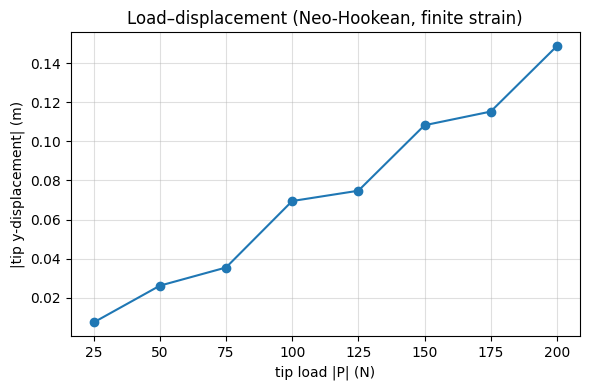

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(load_hist, [abs(d) for d in disp_hist], 'o-', color='C0')
ax.set_xlabel('tip load |P| (N)')
ax.set_ylabel('|tip y-displacement| (m)')
ax.set_title('Load–displacement (Neo-Hookean, finite strain)')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('hyper_load_disp.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Deformed configuration

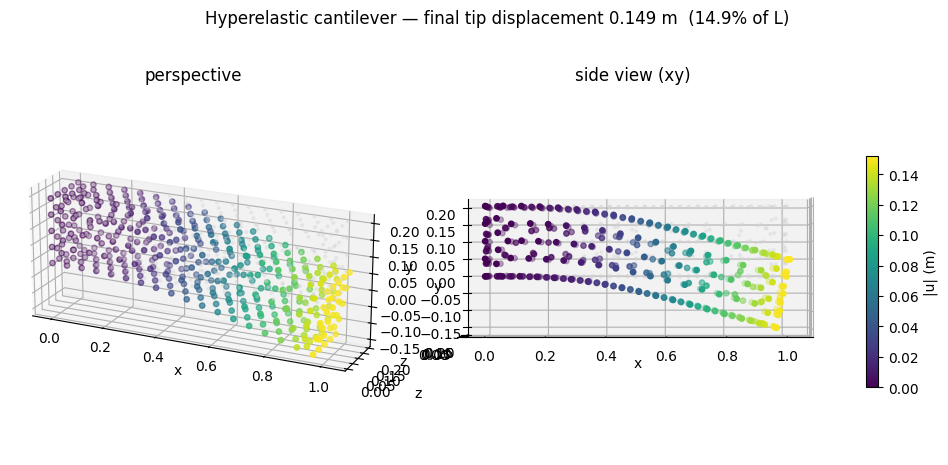

In [7]:
u_np = (u * mask).detach().cpu().numpy()
pts_np = pts.cpu().numpy()
deformed = pts_np + u_np
mag = np.linalg.norm(u_np, axis=1)

fig = plt.figure(figsize=(13, 5))
for k, view in enumerate([(20, -65), (0, -90)]):
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    ax.scatter(pts_np[:, 0], pts_np[:, 2], pts_np[:, 1], c='lightgray', s=4, alpha=0.3, label='undeformed')
    sc = ax.scatter(deformed[:, 0], deformed[:, 2], deformed[:, 1], c=mag, cmap='viridis', s=15)
    ax.set_box_aspect([L, H, max(W, 0.4)])
    ax.view_init(elev=view[0], azim=view[1])
    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
    ax.set_title('perspective' if k == 0 else 'side view (xy)')
plt.colorbar(sc, ax=fig.get_axes(), shrink=0.6, label='|u| (m)')
plt.suptitle(f'Hyperelastic cantilever — final tip displacement {abs(disp_hist[-1]):.3f} m  ({abs(disp_hist[-1])/L*100:.1f}% of L)', y=1.02)
plt.savefig('hyper_deformed.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Summary

* Defined a 6-line Neo-Hookean strain-energy density.
* Assembled the internal energy with one `from_mesh(...)` call.
* Minimized the total potential energy with LBFGS + strong-Wolfe + 8-step load continuation.
* Saw the classic large-deformation nonlinear stiffening curve.

Same script, swap `NeoHookean` for `LinearElasticityElementAssembler` for the small-strain limit, or for a `MooneyRivlin` / `Gent` energy by changing only `element_energy`.